# AlexNet Benchmark

In [1]:
model_name = "AlexNet"

import torch
from torch import nn
from torchvision import models
#import torch_mlir
import numpy as np
import iree.compiler
import iree.runtime

import warnings
warnings.filterwarnings("ignore")

from timeit import timeit as ti
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

from ragdoll.compiler import *
from ragdoll.benchmark import *
import ragdoll

def compile_str_and_load(mlir):
    config = iree.runtime.system_api.Config("local-task")
    vmi = iree.runtime.VmInstance()
    fb_file = ragdoll.compile(mlir, "cpu", "input", "codegen", benchmark=False)
    with open(fb_file, 'rb') as f:
        binary_data = f.read()
    vmm = iree.runtime.VmModule.from_flatbuffer(vmi, binary_data)
    vmo = iree.runtime.load_vm_module(vmm, config)
    return vmo
    #return iree.runtime.load_vm_flatbuffer(
    #    iree.compiler.compile_str(
    #        mlir, input_type="tosa", target_backends=["llvm-cpu"],
    #        extra_args=[
    #            "--iree-llvmcpu-target-cpu-features=host",
    #            "--iree-stream-partitioning-favor=max-concurrency",
    #            "--iree-flow-zero-fill-empty-tensors",
    #            "--iree-llvmcpu-fail-on-out-of-bounds-stack-allocation=0",
    #            "--iree-opt-const-eval",
    #            "--iree-opt-const-expr-hoisting",
    #            "--iree-opt-numeric-precision-reduction",
    #            "--iree-opt-strip-assertions"
    #        ]
    #    ),
    #    backend="llvm-cpu"
    #)

def compile_file_and_load(filename):
    with open(filename) as f:
        return compile_str_and_load(f.read())
    
def get_dataframe(forward, backward, item):
    return pd.concat([
        pd.DataFrame({
            "time": forward,
            "pass": "Forward",
            "item": item
        }, index=[0]),
        pd.DataFrame({
            "time": backward,
            "pass": "Backward",
            "item": item
        }, index=[0]),
        pd.DataFrame({
            "time": forward + backward,
            "pass": "Full",
            "item": item
        }, index=[0]),
    ])

def timeit(stmt, n=100):
    return ti(stmt, globals=globals(), number=n) * 1000 / n

2024-03-16 20:52:32.985964: I tensorflow/stream_executor/platform/default/dso_loader.cc:49] Successfully opened dynamic library libcudart.so.10.1


## Prepare

In [2]:
MAGIC_NUM = 7777e-5
BENCH_REPS = 1
model = models.alexnet(pretrained=False).train(False)
model.load_state_dict({k: torch.ones_like(v) * MAGIC_NUM for k, v in model.state_dict().items()})
model = torch.compile(model, backend="inductor")

recompute, storeall = [
    #compile_file_and_load(x) for x in ["recompute.mlir", "storeall.mlir"]
    ragdoll.compile(x, "cpu", "input", "codegen", benchmark=False) for x in ["recompute.mlir", "storeall.mlir"]
]
recompute_fb, storeall_fb = [
    compile_str_and_load(x) for x in ["recompute.mlir", "storeall.mlir"]
    #ragdoll.compile(x, "cpu", "input", "codegen") for x in ["recompute.mlir", "storeall.mlir"]
]

## Experimental

In [3]:
image = torch.randn(1, 3, 224, 224, requires_grad=True)
output = model(image)
grad = torch.randn_like(output)

image_np = image.detach().numpy()
grad_np = grad.numpy()

df = pd.DataFrame()
df_bench = pd.DataFrame()

### PyTorch (Baseline)

In [4]:
baseline_f = torch_model_benchmark(model, 
                                 [image], 
                                 device='cpu',
                                 warmups=2,
                                 repetitions=17, 
                                 measure_count=11)
baseline_f = np.mean(baseline_f)
print(baseline_f)

baseline_b = torch_model_benchmark(torch.autograd.grad, 
                                 [output, [image], grad], 
                                 device='cpu',
                                 warmups=2,
                                 repetitions=17, 
                                 measure_count=11)
baseline_b = np.mean(baseline_b)
print(baseline_b)
df = pd.concat([df, get_dataframe(baseline_f, baseline_b, "Torch Dynamo")])
print(df)

25.875522523777548
106.80426606068424
         time      pass          item
0   25.875523   Forward  Torch Dynamo
0  106.804266  Backward  Torch Dynamo
0  132.679789      Full  Torch Dynamo


### Nabla without Optim

In [5]:
f1 = timeit("recompute_fb.forward(image_np)") / BENCH_REPS
f2 = ragdoll_model_benchmark(
    recompute,
    "forward",
    [(1, 3, 224, 224)], 
    device='cpu',
    warmups=2,
    repetitions=BENCH_REPS, 
    measure_count=11)

f2 = np.mean(f2)
print(f1)
print(f2)

(1, 3, 224, 224)
['1x3x224x224xf32']
25.67200757563114
24.254545454545454


In [7]:
b = timeit("recompute_fb.dforward(grad_np)") / BENCH_REPS
print(b)
# TODO(albert): unresolved value error
#b2 = ragdoll_model_benchmark(
#    recompute,
#    "dforward",
#    [(1, 1000)],
#    device='cpu',
#    warmups=2,
#    repetitions=1, 
#    measure_count=11)

df = pd.concat([df, get_dataframe(f2, b, "Nabla")])
print(df)

36.649956377223134
         time      pass          item
0   25.875523   Forward  Torch Dynamo
0  106.804266  Backward  Torch Dynamo
0  132.679789      Full  Torch Dynamo
0   24.254545   Forward         Nabla
0   36.649956  Backward         Nabla
0   60.904502      Full         Nabla


### Nabla with Optim

In [8]:
f = timeit("storeall_fb.forward(image_np)") / BENCH_REPS
f2 = ragdoll_model_benchmark(
    storeall,
    "forward",
    [(1, 3, 224, 224)], 
    device='cpu',
    warmups=2,
    repetitions=BENCH_REPS, 
    measure_count=11)
b = timeit("storeall_fb.dforward(grad_np)") / BENCH_REPS
print(f)
print(np.mean(f2))
df = pd.concat([df, get_dataframe(np.mean(f2), b, "Nabla Optim")])
print(df)

(1, 3, 224, 224)
['1x3x224x224xf32']
31.204315209761262
29.590909090909097
         time      pass          item
0   25.875523   Forward  Torch Dynamo
0  106.804266  Backward  Torch Dynamo
0  132.679789      Full  Torch Dynamo
0   24.254545   Forward         Nabla
0   36.649956  Backward         Nabla
0   60.904502      Full         Nabla
0   29.590909   Forward   Nabla Optim
0   43.007644  Backward   Nabla Optim
0   72.598553      Full   Nabla Optim


In [9]:
df.style.hide(axis="index")

time,pass,item
25.875523,Forward,Torch Dynamo
106.804266,Backward,Torch Dynamo
132.679789,Full,Torch Dynamo
24.254545,Forward,Nabla
36.649956,Backward,Nabla
60.904502,Full,Nabla
29.590909,Forward,Nabla Optim
43.007644,Backward,Nabla Optim
72.598553,Full,Nabla Optim


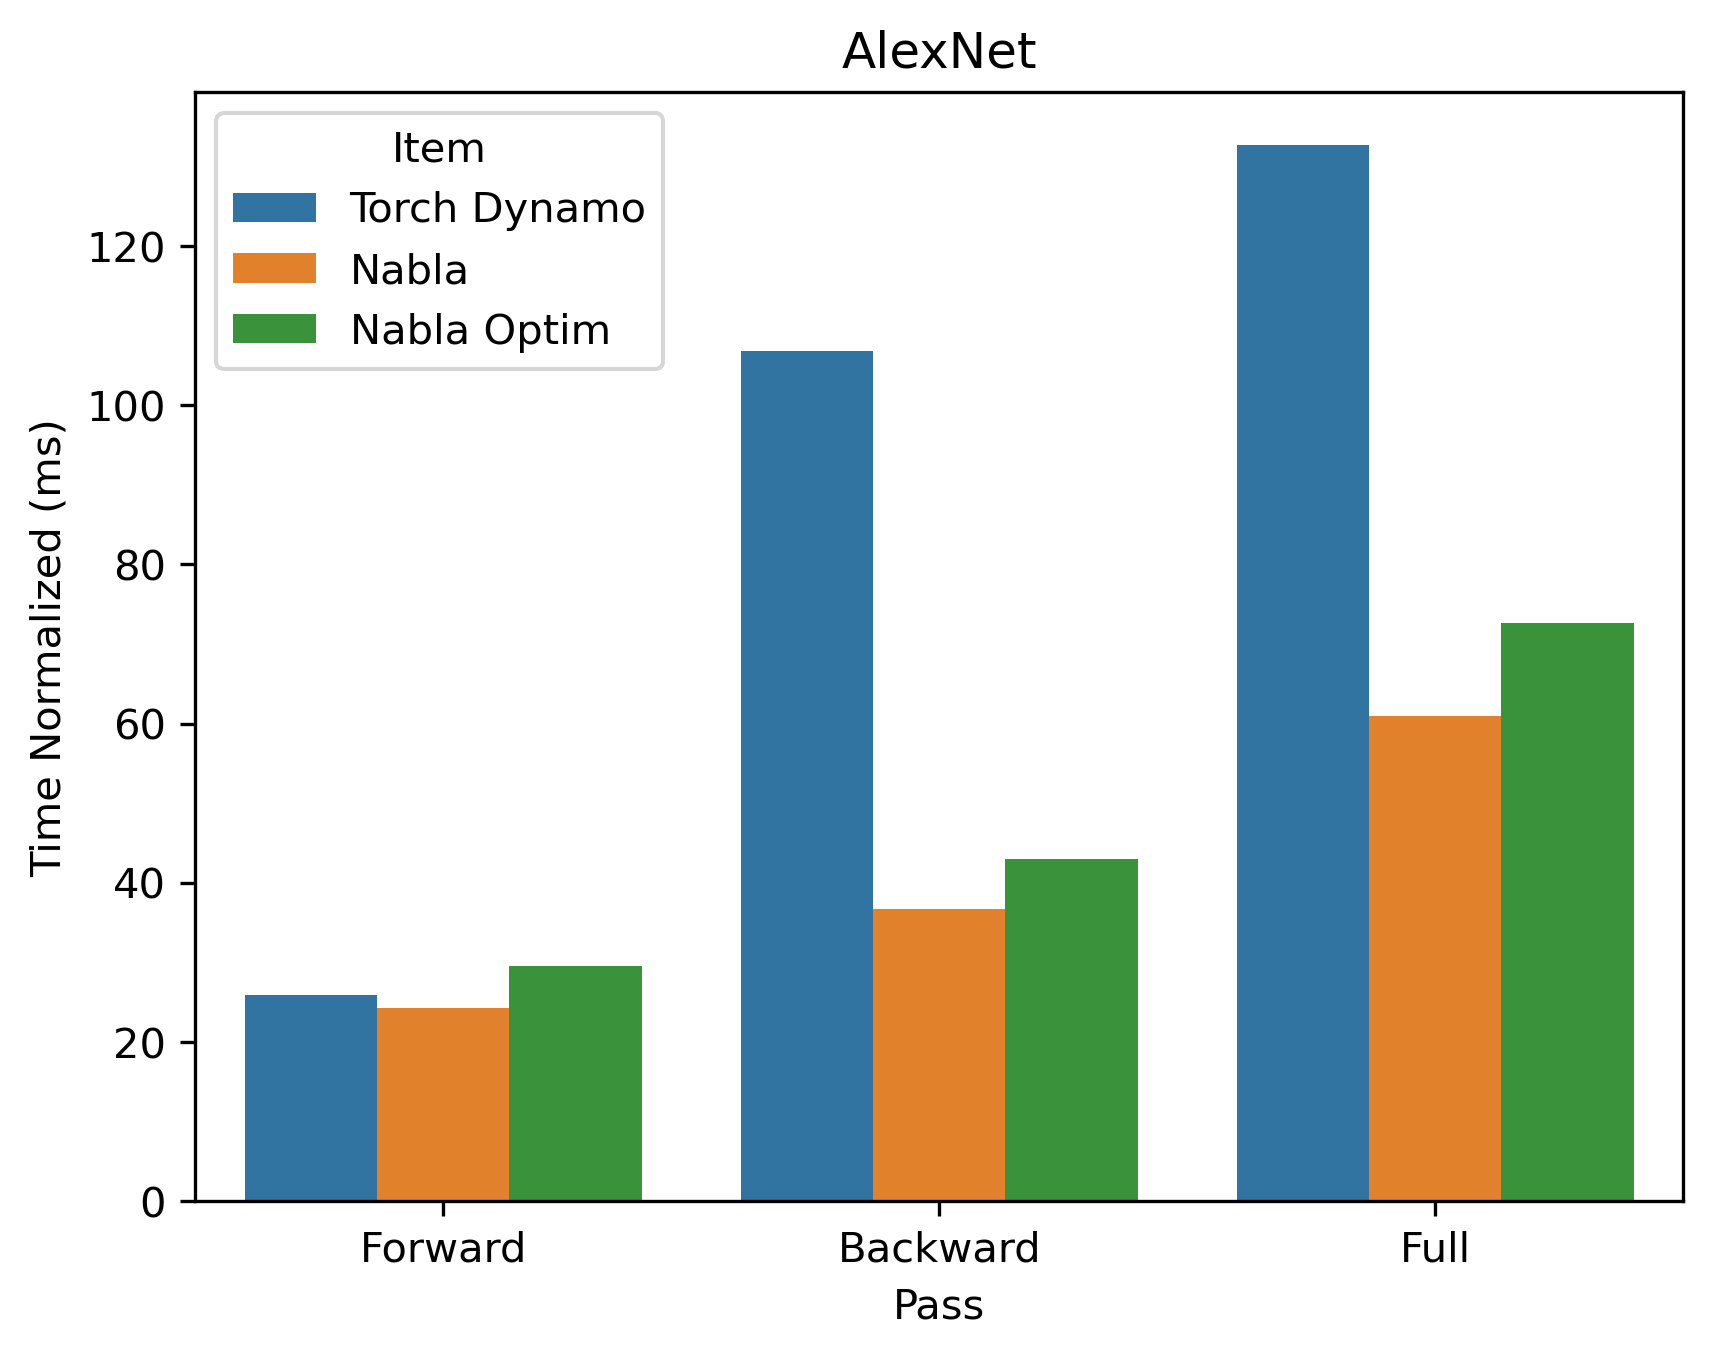

In [10]:
plt.rcParams["figure.dpi"] = 300

sns.barplot(df, x="pass", y="time", hue="item")
plt.xlabel("Pass")
plt.ylabel("Time Normalized (ms)")
plt.legend().set_title("Item")
plt.title(model_name)

plt.savefig(f"{model_name}-time.png")

In [11]:
forward = df[df["pass"] == "Forward"]
forward["acceleration"] = baseline_f / forward["time"]
forward

,time,pass,item,acceleration
0,25.875523,Forward,Torch Dynamo,1.000000
0,24.254545,Forward,Nabla,1.066832
0,29.590909,Forward,Nabla Optim,0.874442


In [12]:
backward = df[df["pass"] == "Backward"]
backward["acceleration"] = baseline_b / backward["time"]
backward

,time,pass,item,acceleration
0,106.804266,Backward,Torch Dynamo,1.000000
0,36.649956,Backward,Nabla,2.914172
0,43.007644,Backward,Nabla Optim,2.483379


In [13]:
full = df[df["pass"] == "Full"]
full["acceleration"] = (baseline_b + baseline_f) / full["time"]
full

,time,pass,item,acceleration
0,132.679789,Full,Torch Dynamo,1.000000
0,60.904502,Full,Nabla,2.178489
0,72.598553,Full,Nabla Optim,1.827582


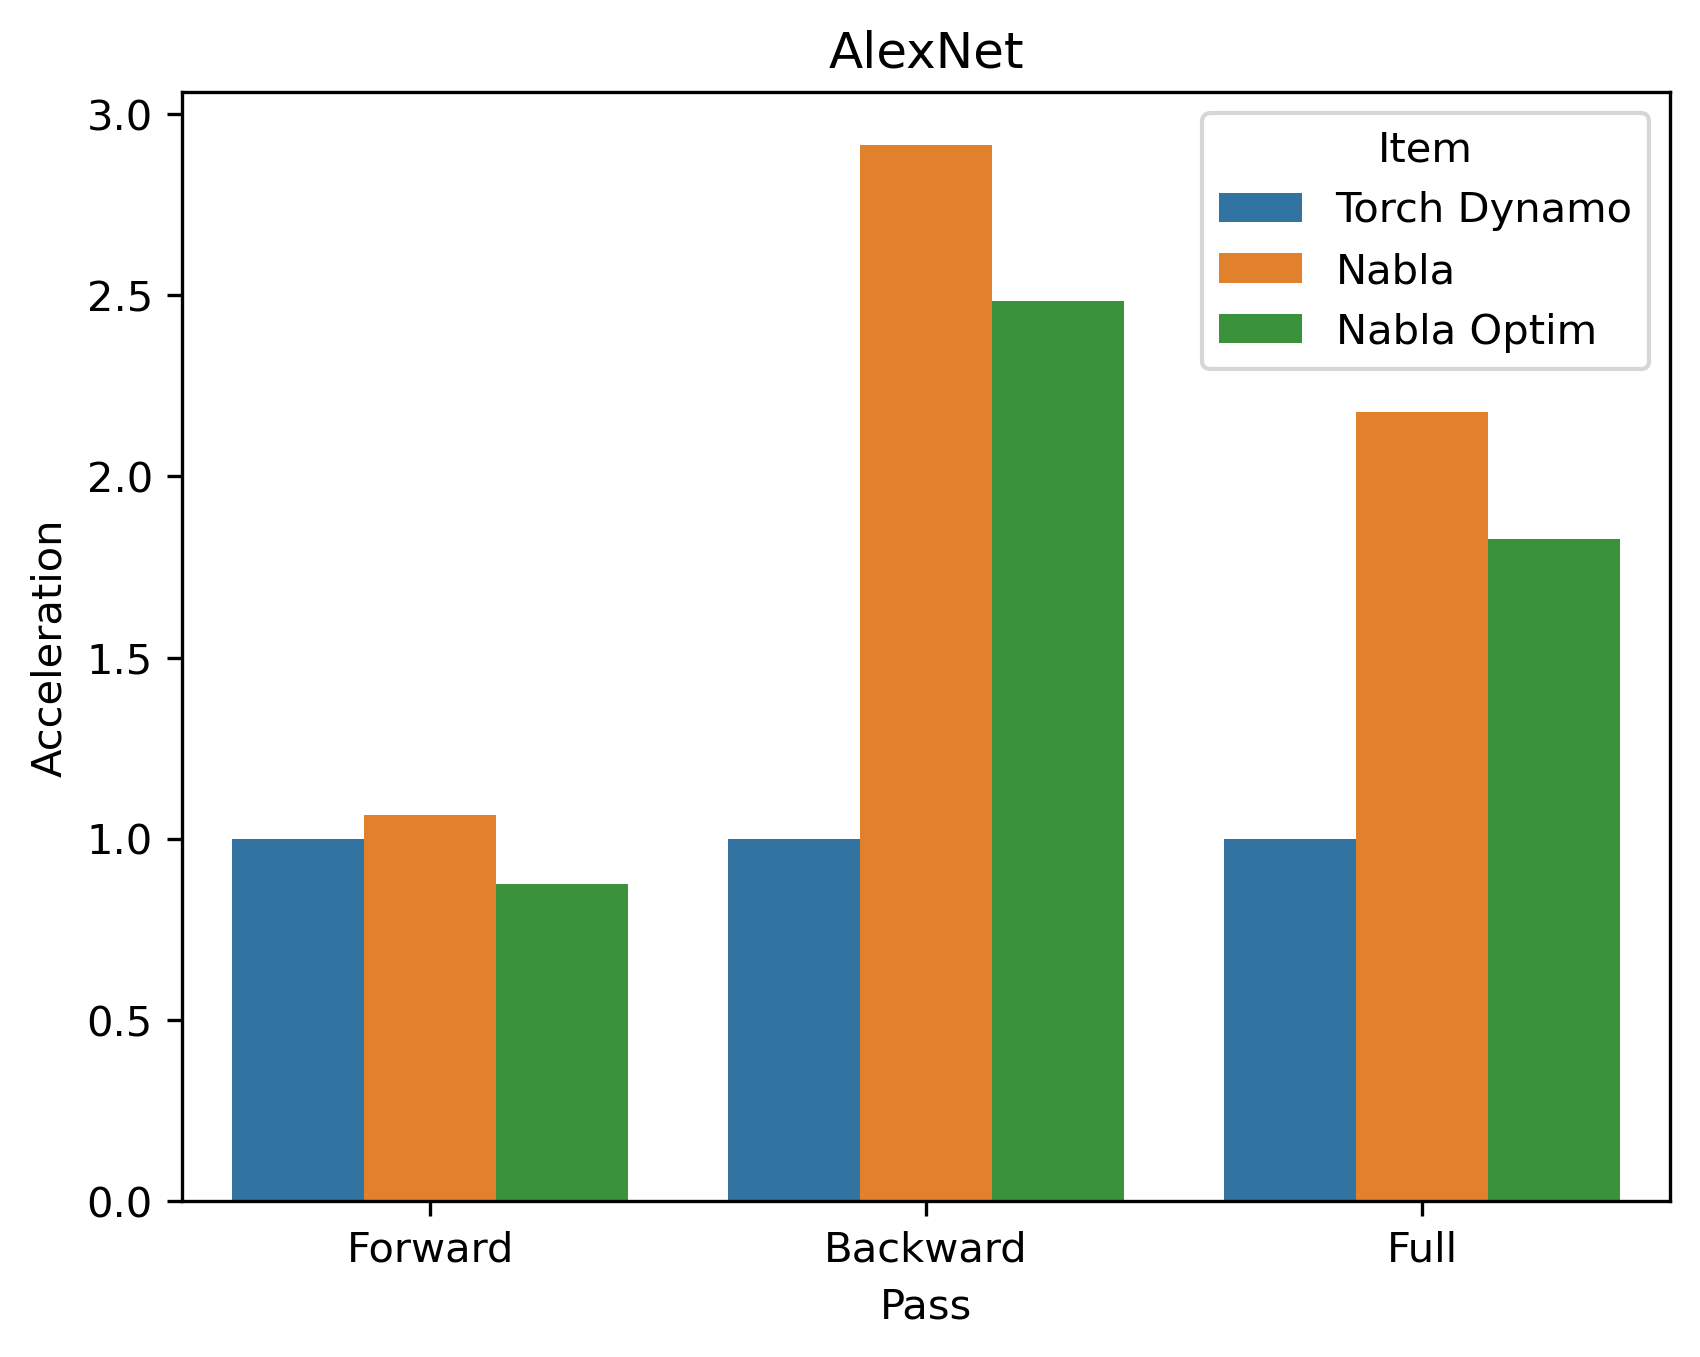

In [14]:
df = pd.concat([forward, backward, full])
df.to_csv(f"{model_name}.csv")

sns.barplot(df, x="pass", y="acceleration", hue="item")
plt.xlabel("Pass")
plt.ylabel("Acceleration")
plt.legend().set_title("Item")
plt.title(model_name)

plt.savefig(f"{model_name}-acceleration.png")